# DESeq2
# Phase 1 vs. Phase 1

focusing on pairwise comparisons involving oysters that experienced only **one** phase 1 (one exposure)

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano)
library(vegan)
library(pheatmap)
library(RColorBrewer)

## 1. read counts matrix and meta data

### counts matrix

In [3]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts <- counts %>%
select(-Gene_ID, -Length)

head(counts)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC111116054,2,1,6,10,9,16,0,10,22,9,⋯,9,2,8,5,2,19,1,2,1,0
LOC111126949,885,652,477,654,586,523,392,357,496,540,⋯,407,740,707,406,418,424,492,330,281,599
LOC111110729,64,209,93,63,100,177,76,98,235,181,⋯,70,149,121,115,126,108,118,115,127,213
LOC111112434,11,7,2,0,2,2,12,15,10,36,⋯,11,6,4,0,2,16,22,0,8,0
LOC111120752,360,586,336,426,351,417,236,278,761,373,⋯,359,345,438,278,287,416,621,251,333,430
LOC111128944,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,1,0,0


### meta data

In [4]:
# create df with col names from counts matrix
meta <- as.data.frame(colnames(counts))

colnames(meta) <- 'Sample'

# Separate into columns
meta <- meta %>%
   # Keep original SampleID
  mutate(OGSample = Sample) %>%
  # Split by '_'
  separate(Sample, into = c("Phase1", "Phase2", "Tag"), sep = "_") %>%
  mutate(
    Phase1_Treatment = substr(Phase1, 1, 1),
    Phase1_TankRep    = as.numeric(substr(Phase1, 2, nchar(Phase1))),
    Phase2_Treatment = gsub("[0-9]", "", Phase2),
    Phase2_TankRep       = as.numeric(gsub("[A-Za-z]", "", Phase2))
  ) %>%
  select(OGSample, Phase1_Treatment, Phase1_TankRep, Phase2_Treatment, Phase2_TankRep, Tag)

colnames(meta)[1] <- 'Sample'

head(meta)

,Sample,Phase1_Treatment,Phase1_TankRep,Phase2_Treatment,Phase2_TankRep,Tag
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>
1,B1_B1_O01,B,1,B,1,O01
2,B1_Nu_O03,B,1,Nu,NA,O03
3,B1_W5_O50,B,1,W,5,O50
4,B2_B5_O51,B,2,B,5,O51
5,B2_C4_O40,B,2,C,4,O40
6,B2_Nu_O12,B,2,Nu,NA,O12


In [5]:
# adding treatment info
meta2 <- meta %>%
mutate(
    ## phase 1 treatments
    # overall
    Phase1_treatment = case_when(
        Phase1_Treatment == 'B' ~ 'both',
        Phase1_Treatment == 'H' ~ 'hypoxic',
        Phase1_Treatment == 'W' ~ 'warm',
        Phase1_Treatment == 'C' ~ 'control',
    TRUE ~ NA_character_),
    
    # temp
    Phase1_temp = case_when(
        Phase1_Treatment == 'B' ~ 'warm',
        Phase1_Treatment == 'H' ~ 'ambient',
        Phase1_Treatment == 'W' ~ 'warm',
        Phase1_Treatment == 'C' ~ 'ambient',
    TRUE ~ NA_character_),

    # dissolved oxygen
    Phase1_DO = case_when(
        Phase1_Treatment == 'B' ~ 'hypoxic',
        Phase1_Treatment == 'H' ~ 'hypoxic',
        Phase1_Treatment == 'W' ~ 'normoxic',
        Phase1_Treatment == 'C' ~ 'normoxic',
    TRUE ~ NA_character_),
    
    ## phase 2 treatments
    # overall
    Phase2_treatment = case_when(
        Phase2_Treatment == 'B' ~ 'both',
        Phase2_Treatment == 'H' ~ 'hypoxic',
        Phase2_Treatment == 'W' ~ 'warm',
        Phase2_Treatment == 'C' ~ 'control',
    TRUE ~ NA_character_),
    
    # temp
    Phase2_temp = case_when(
        Phase2_Treatment == 'B' ~ 'warm',
        Phase2_Treatment == 'H' ~ 'ambient',
        Phase2_Treatment == 'W' ~ 'warm',
        Phase2_Treatment == 'C' ~ 'ambient',
    TRUE ~ NA_character_),

    # dissolved oxygen
    Phase2_DO = case_when(
        Phase2_Treatment == 'B' ~ 'hypoxic',
        Phase2_Treatment == 'H' ~ 'hypoxic',
        Phase2_Treatment == 'W' ~ 'normoxic',
        Phase2_Treatment == 'C' ~ 'normoxic',
    TRUE ~ NA_character_)) %>%
select(Sample, Phase1_treatment, Phase1_temp, Phase1_DO, Phase1_TankRep, Phase2_treatment, Phase2_temp, Phase2_DO, Phase2_TankRep)

head(meta2)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


In [6]:
#write.csv(meta2, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/sample_metaData.csv', row.names=FALSE)

for this analysis, only looking at Phase 1 samples, so pulling those out

In [7]:
# if skipped above code:
meta2 <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/sample_metaData.csv')

In [6]:
# selecting only phase 1 sample
p1_meta <- meta2 %>%
filter(grepl("Nu", Sample)) %>%
filter(Sample != 'B3_Nu_O24') # this sample failed all QC steps, removing from analysis

# setting samples as rownames and deleting col from df
rownames(p1_meta) <- p1_meta$Sample
p1_meta <- p1_meta[, !colnames(p1_meta) %in% "Sample"]

p1_meta

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA
C1_Nu_W05,control,ambient,normoxic,1,NA,NA,NA,NA
C2_Nu_W15,control,ambient,normoxic,2,NA,NA,NA,NA
C3_Nu_W21,control,ambient,normoxic,3,NA,NA,NA,NA


In [7]:
# pulling out only phase 1 counts
p1_counts <- counts[,colnames(counts) %in% rownames(p1_meta)]
head(p1_counts)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC111116054,1,16,13,11,1,16,2,1,2,10,⋯,16,29,15,0,3,23,12,9,1,2
LOC111126949,652,523,444,1438,609,525,1076,541,566,613,⋯,451,608,745,394,1362,1235,270,407,492,330
LOC111110729,209,177,207,154,184,148,144,161,155,259,⋯,136,151,221,143,231,64,91,140,118,115
LOC111112434,7,2,10,19,18,11,17,21,18,18,⋯,6,6,25,5,24,0,10,7,22,0
LOC111120752,586,417,388,202,330,848,236,156,699,712,⋯,278,406,282,230,430,458,929,433,621,251
LOC111128944,0,0,0,0,0,0,2,4,0,6,⋯,14,2,0,0,2,0,4,0,0,1


In [9]:
# setting the same order for counts matrix and meta data
p1_counts <- p1_counts[,rownames(p1_meta)]
all(rownames(p1_meta) == colnames(p1_counts))

[1] TRUE

## 2. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [10]:
# overall phase 1 treatment
p1_meta$Phase1_treatment <- factor(p1_meta$Phase1_treatment,
                                   levels = c('control', 'both', 'hypoxic', 'warm'))

In [11]:
# phase 1 tempature
p1_meta$Phase1_temp <- factor(p1_meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

In [12]:
# phase 1 DO
p1_meta$Phase1_DO <- factor(p1_meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

### phase 1 overall treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [13]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = p1_counts,
                              colData = p1_meta,
                              design = ~ Phase1_treatment)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

class: DESeqDataSet 
dim: 38838 23 
metadata(1): version
assays(1): counts
rownames(38838): LOC111116054 LOC111126949 ... ND1 ND4L
rowData names(0):
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(8): Phase1_treatment Phase1_temp ... Phase2_DO
  Phase2_TankRep

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"                           "Phase1_treatment_both_vs_control"   
[3] "Phase1_treatment_hypoxic_vs_control" "Phase1_treatment_warm_vs_control"

In [19]:
vsd <- vst(dds, blind = TRUE) # DESeq "forgets" the design/groups, applies vst evenly across samples
head(assay(vsd))

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC111116054,5.745395,6.362797,6.239272,6.284222,5.765808,6.328434,5.858836,5.766649,5.811778,6.101841,⋯,6.485918,6.633017,6.365967,5.551009,5.864300,6.623031,6.247438,6.151223,5.760385,5.883052
LOC111126949,9.335715,9.200133,8.846718,10.739705,9.501493,9.096392,10.281576,9.362266,9.034074,9.004387,⋯,9.377478,9.387546,9.738418,9.245158,10.102582,10.595725,8.400395,8.849560,9.171532,8.968566
LOC111110729,8.042121,7.986954,8.013536,8.013902,8.115955,7.730820,7.899824,7.989067,7.657596,8.047870,⋯,8.014332,7.832874,8.290414,8.094090,8.000521,7.276071,7.365516,7.724064,7.640053,7.829965
LOC111112434,6.063003,5.841331,6.155955,6.507433,6.448616,6.198007,6.436223,6.521701,6.325064,6.286533,⋯,6.129704,6.052261,6.594278,6.087444,6.425426,5.551009,6.187768,6.081185,6.515847,5.551009
LOC111120752,9.203492,8.926122,8.690000,8.294488,8.755819,9.697479,8.409925,7.957863,9.292464,9.186248,⋯,8.791264,8.894762,8.557447,8.606397,8.667115,9.299029,9.897539,8.922788,9.461362,8.648698
LOC111128944,5.551009,5.551009,5.551009,5.551009,5.551009,5.551009,5.858836,5.981096,5.551009,5.978710,⋯,6.427382,5.841375,5.551009,5.551009,5.806977,5.551009,5.955680,5.551009,5.551009,5.786058


In [15]:
write.csv(assay(vsd), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/p1_vst.csv')

### diagnostic tests

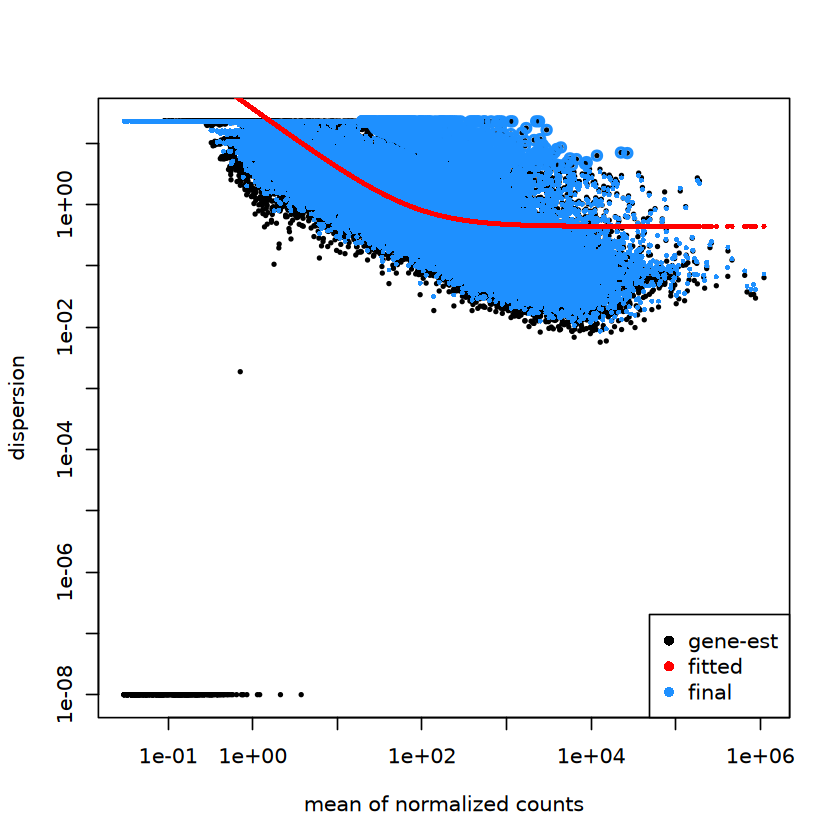

In [11]:
plotDispEsts(dds)

## nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [12]:
# normalization & transformation
vsd <- vst(dds)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.0000,203.1140,195.1039,182.3211,173.9018,186.4840,185.8846,194.2911,181.2699,177.4347,⋯,211.8518,180.8692,178.8295,233.2292,191.3068,185.8885,174.1291,189.3901,169.0272,183.3507
B2_Nu_O12,203.1140,0.0000,178.3912,224.8518,213.4442,172.7770,194.9357,195.8964,191.0631,178.5330,⋯,186.3116,184.3246,214.6065,181.7933,184.5361,188.9821,190.1781,178.9019,210.4078,180.6837
B4_Nu_O32,195.1039,178.3912,0.0000,205.5049,198.6306,181.8347,181.4200,179.4273,178.7899,178.1022,⋯,189.0395,126.0233,199.5181,185.4816,176.9057,187.3434,192.8283,172.0237,209.2349,176.0272
B5_Nu_O36,182.3211,224.8518,205.5049,0.0000,172.5582,211.8919,193.3972,193.9310,186.4933,199.6367,⋯,225.9119,192.8199,179.2042,242.3882,195.0745,207.8053,212.5983,203.4372,198.4277,197.2967
B6_Nu_O47,173.9018,213.4442,198.6306,172.5582,0.0000,199.7950,189.8460,179.9627,183.4983,186.9331,⋯,205.7215,181.2779,173.4026,236.0590,179.8949,200.6794,201.7968,180.3279,186.0423,183.6095
C1_Nu_W01,186.4840,172.7770,181.8347,211.8919,199.7950,0.0000,182.8328,188.5758,183.8515,167.4244,⋯,187.1119,181.0015,204.9816,195.6153,172.3426,182.1973,183.9683,173.0938,196.0589,175.4917


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
B1_Nu_O03,63.80163,-38.906364,both,warm,hypoxic,1,NA,NA,NA,NA,1.1731259
B2_Nu_O12,-67.30304,-37.460503,both,warm,hypoxic,2,NA,NA,NA,NA,1.0498679
B4_Nu_O32,-35.37400,-3.668274,both,warm,hypoxic,4,NA,NA,NA,NA,1.1954800
B5_Nu_O36,88.64184,18.765606,both,warm,hypoxic,5,NA,NA,NA,NA,0.8890653
B6_Nu_O47,73.26232,9.041074,both,warm,hypoxic,6,NA,NA,NA,NA,0.9604278
C1_Nu_W01,-36.51973,-43.335119,control,ambient,normoxic,1,NA,NA,NA,NA,1.1472252


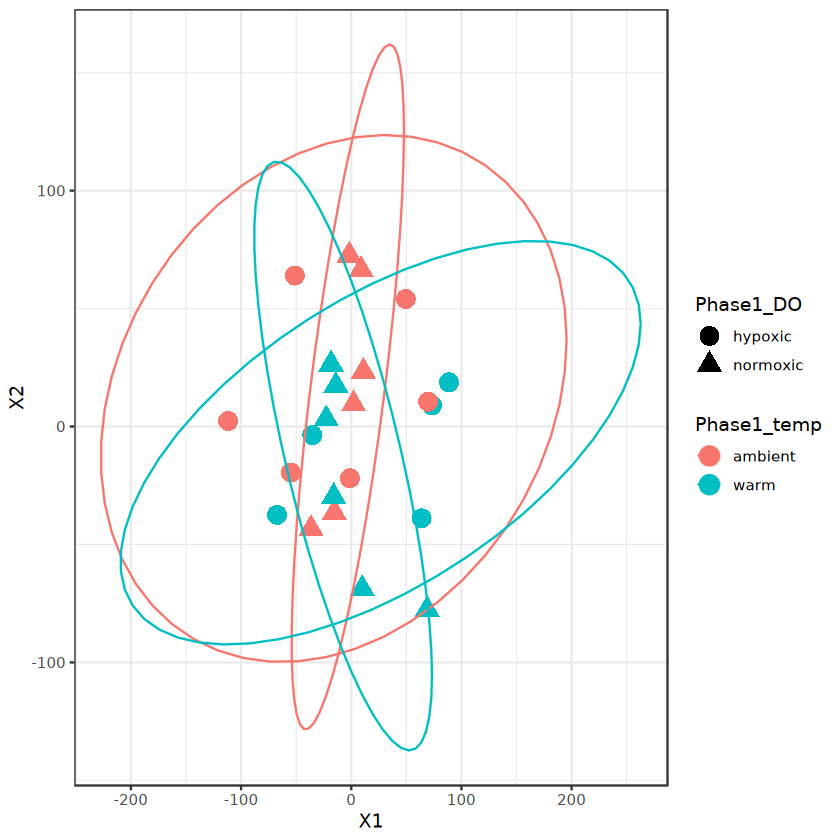

In [13]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

There doesn't appear to be any strong patterns of gene expression among the different phase 1 treatments

but the warm treatment looks less disperse than ambient treatment

#### permANOVA

In [22]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO, data = meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,20561.28,0.05217778,1.1451747,0.186
Phase1_DO,1,17149.43,0.04351964,0.9551496,0.541
Phase1_temp:Phase1_DO,1,15211.77,0.03860248,0.8472301,0.804
Residual,19,341139.46,0.86570010,NA,NA
Total,22,394061.94,1.00000000,NA,NA


permANOVA confirms that there isn't any statistically significant differences in gene expression patterns among phase 1 treatments 

### heatmap

In [18]:
# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 203.1140 195.1039 182.3211 173.9018 186.4840 185.8846

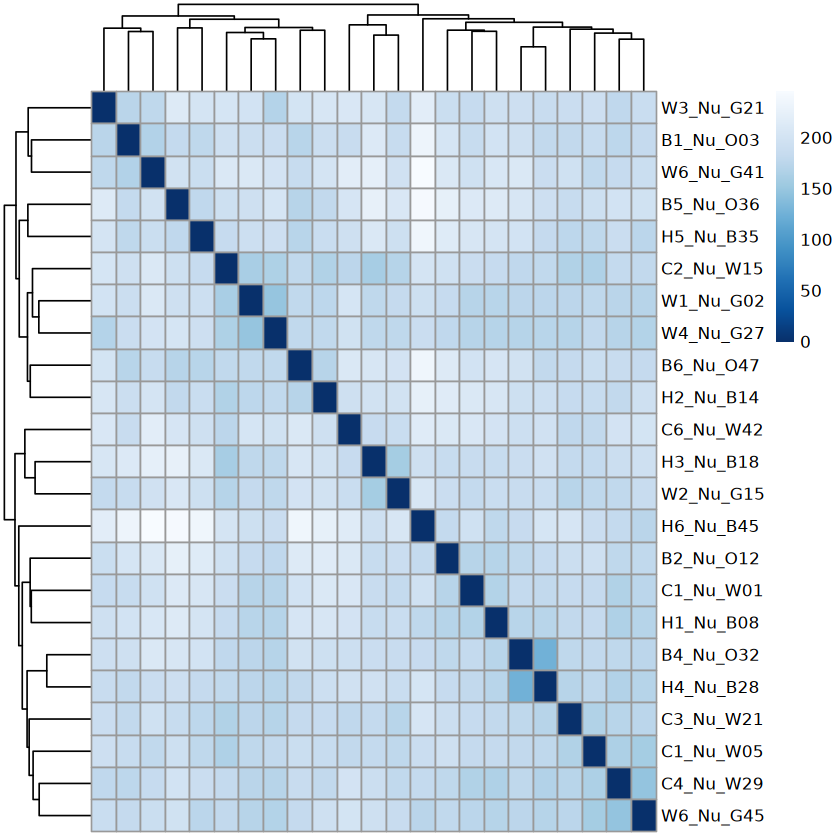

In [19]:
sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

### comparisons vs. control
applying `ashr` lfc shrinkage estimator - DESeq docs recommend `apeglm` but cannot use that for comparisons below so I want everything to be consistent

#### warm vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 34981 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 40, 0.11%
LFC < -1.00 (down) : 43, 0.12%



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,8.739763,0.0074950585,0.10558228,0.74682942,0.45516653,0.9628155,0.9807342,0.8524235,15.240013,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,670.509082,-0.0008413902,0.06985372,-0.07440747,0.94068617,0.9983738,0.9884736,555.7800963,498.157926,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,160.018313,-0.0659273934,0.13361271,-2.17370214,0.02972751,0.5352822,0.9883602,178.1565033,168.592644,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,13.048074,-0.0124548994,0.10906395,-1.10600106,0.26872606,0.8946927,0.9790219,5.9669642,1.905002,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,403.233517,0.0128102465,0.07701770,0.96151858,0.33629149,0.9266293,0.9876052,499.5201479,397.192840,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,1.594569,-0.0034572092,0.17695747,-0.28291702,0.77724045,NA,0.9760533,0.0000000,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


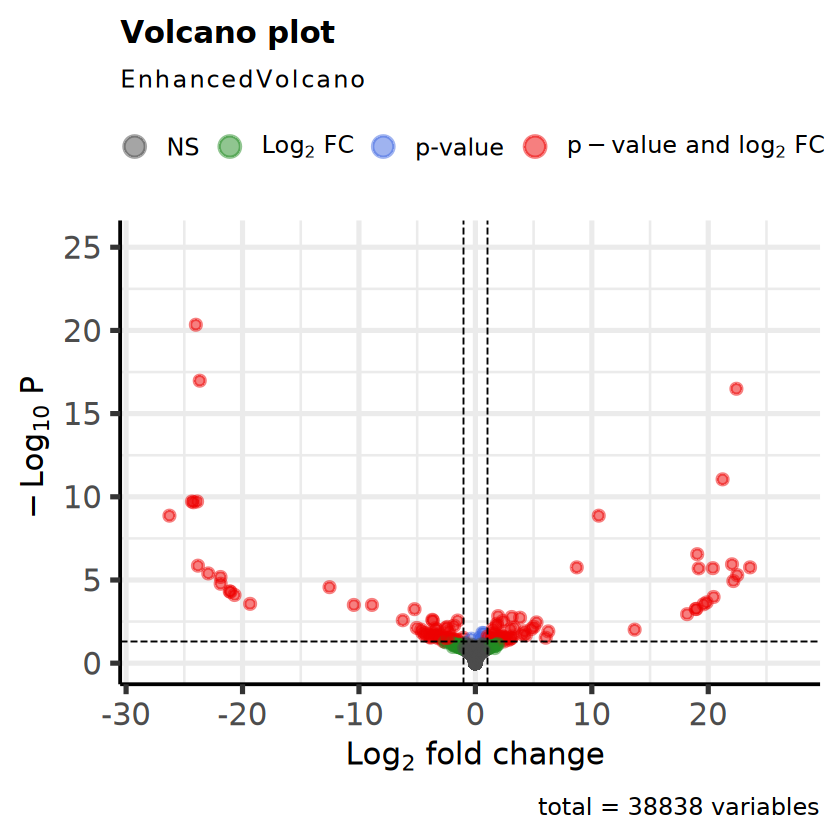

In [14]:
# phase 1 warm vs. control
res.warmLFC <- lfcShrink(dds, 
                         coef=4, 
                         type = 'ashr',
                        lfcThreshold = 1)

summary(res.warmLFC)

EnhancedVolcano(res.warmLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.warmLFC <- merge(res.warmLFC, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.warmLFC)[1] <- 'Gene'
head(res.warmLFC)

In [15]:
write.csv(as.data.frame(res.warmLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.warm_v_cont.csv')

#### hypoxic vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 34981 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 37, 0.11%
LFC < -1.00 (down) : 37, 0.11%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,8.739763,0.0035435648,0.06037463,1.3623197,0.1730970,0.9996562,0.9878166,0.8524235,15.240013,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,670.509082,-0.0013231916,0.04137473,-0.3341942,0.7382330,0.9996562,0.9951125,555.7800963,498.157926,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,160.018313,0.0058289043,0.04016172,0.7394720,0.4596204,0.9996562,0.9961104,178.1565033,168.592644,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,13.048074,-0.0005556213,0.04320966,-0.2228811,0.8236281,0.9996562,0.9940476,5.9669642,1.905002,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,403.233517,-0.0030826249,0.04121809,-0.6537844,0.5132507,0.9996562,0.9952320,499.5201479,397.192840,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,1.594569,0.0009816089,0.08400785,0.3698951,0.7114607,0.9996562,0.9887849,0.0000000,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


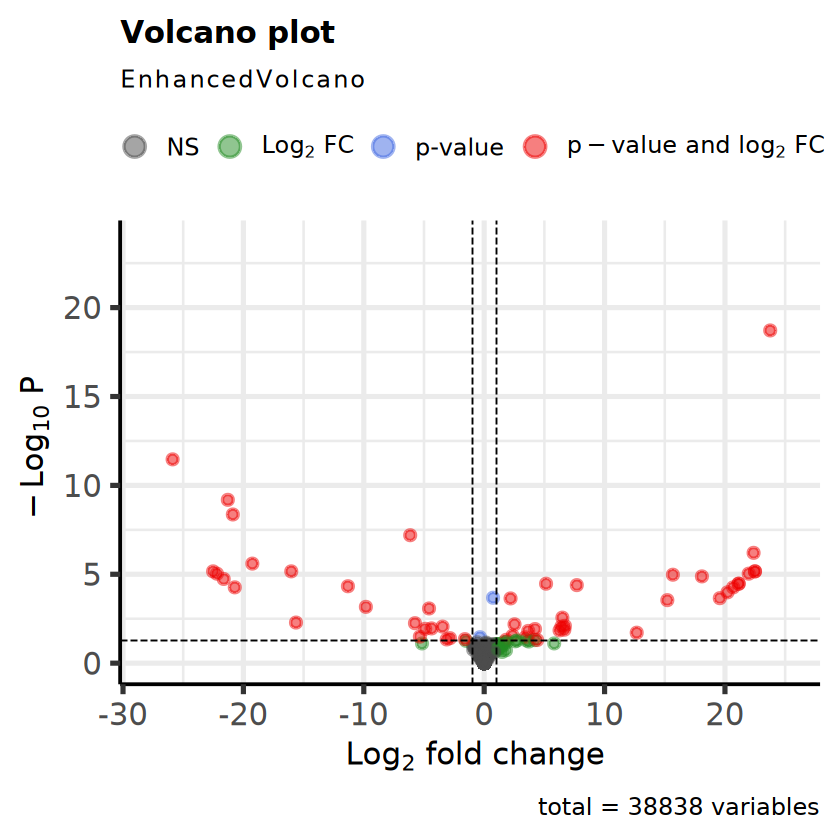

In [16]:
# phase 1 hypoxic vs. control
res.hypoxicLFC <- lfcShrink(dds, 
                            coef=3,
                            type = 'ashr',
                           lfcThreshold =1)

summary(res.hypoxicLFC)

EnhancedVolcano(res.hypoxicLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hypoxicLFC <- merge(res.hypoxicLFC, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hypoxicLFC)[1] <- 'Gene'
head(res.hypoxicLFC)

In [17]:
write.csv(as.data.frame(res.hypoxicLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.hyp_v_cont.csv')

#### both vs. control

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 34981 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 37, 0.11%
LFC < -1.00 (down) : 105, 0.3%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,8.739763,0.003918629,0.08851595,0.6101687,0.5417500,0.9863770,0.9689312,0.8524235,15.240013,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,670.509082,0.001028526,0.04325616,0.2542243,0.7993223,0.9996341,0.9797357,555.7800963,498.157926,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,160.018313,0.001896210,0.02965754,0.5218944,0.6017438,0.9904983,0.9837408,178.1565033,168.592644,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,13.048074,-0.004022700,0.07571793,-0.7249581,0.4684777,0.9769627,0.9707931,5.9669642,1.905002,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,403.233517,-0.001715556,0.04025490,-0.4217741,0.6731899,0.9973811,0.9807015,499.5201479,397.192840,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,1.594569,-0.037626894,0.40747178,-1.2372060,0.2160106,NA,0.8555551,0.0000000,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


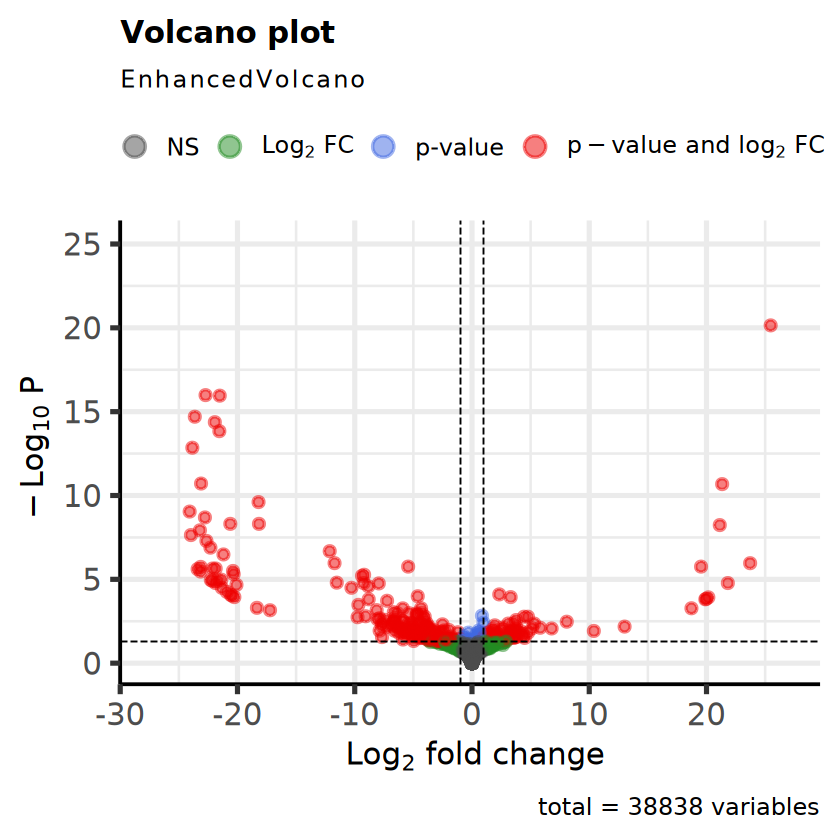

In [18]:
# phase 1 both vs. control
res.bothLFC <- lfcShrink(dds, 
                         coef=2, 
                         type = 'ashr', 
                        lfcThreshold = 1)

summary(res.bothLFC)

EnhancedVolcano(res.bothLFC,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bothLFC <- merge(res.bothLFC, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bothLFC)[1] <- 'Gene'
head(res.bothLFC)

In [19]:
write.csv(as.data.frame(res.bothLFC), '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.both_v_cont.csv')

### other comparisons
(outside of just doing treatment vs. control)

using `ashr` for lfc shrinkage estimator (same as above)

#### warm vs. hypoxic

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 34981 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 45, 0.13%
LFC < -1.00 (down) : 41, 0.12%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,8.739763,0.02105434,0.1794452,0.6185773,0.536194836,0.9099615,0.9815897,0.8524235,15.240013,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,670.509082,-0.01356614,0.1504477,-0.2597788,0.795034412,0.9689757,0.9877713,555.7800963,498.157926,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,160.018313,0.26573141,0.1871541,2.9046833,0.003676249,0.2214613,0.9838839,178.1565033,168.592644,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,13.048074,0.03445700,0.1788035,0.8813930,0.378105153,0.8512991,0.9802036,5.9669642,1.905002,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,403.233517,-0.10339030,0.1710581,-1.6146539,0.106385661,0.6388378,0.9831731,499.5201479,397.192840,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,1.594569,0.01279670,0.2300075,0.6504688,0.515389473,0.9041197,0.9699910,0.0000000,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


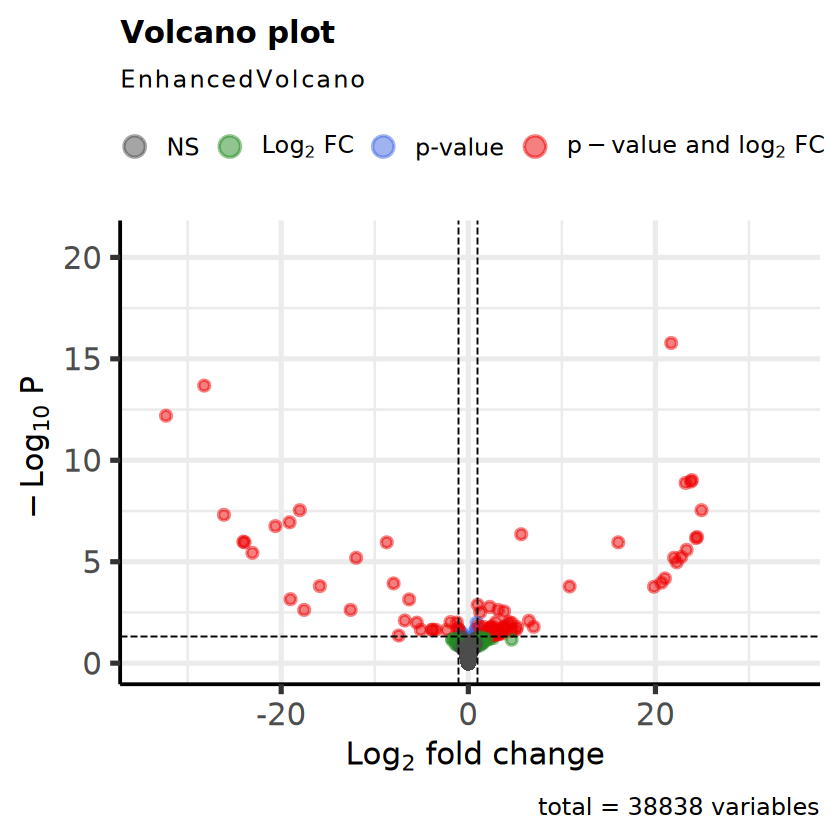

In [20]:
res.w.h <- lfcShrink(dds, 
                     contrast= c('Phase1_treatment', 'hypoxic', 'warm'), # warm is the "control"
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.w.h)

EnhancedVolcano(res.w.h,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.w.h <- merge(res.w.h, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.w.h)[1] <- 'Gene'
head(res.w.h)

In [21]:
write.csv(res.w.h, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.hyp_v_warm.csv')

#### warm vs. both

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 34981 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 83, 0.24%
LFC < -1.00 (down) : 47, 0.13%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,8.739763,0.001829289,0.1307206,0.1033095,0.917717303,0.9921758,0.9802539,0.8524235,15.240013,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,670.509082,-0.009479290,0.1151300,-0.3251544,0.745064231,0.9719153,0.9846577,555.7800963,498.157926,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,160.018313,-0.144957570,0.1412530,-2.5948696,0.009462682,0.2969110,0.9821668,178.1565033,168.592644,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,13.048074,-0.006558018,0.1264564,-0.3309783,0.740660876,0.9715949,0.9805550,5.9669642,1.905002,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,403.233517,0.046724280,0.1212904,1.3383040,0.180797352,0.7534842,0.9819196,499.5201479,397.192840,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,1.594569,0.019393192,0.2786881,0.9673838,0.333352189,NA,0.9396585,0.0000000,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


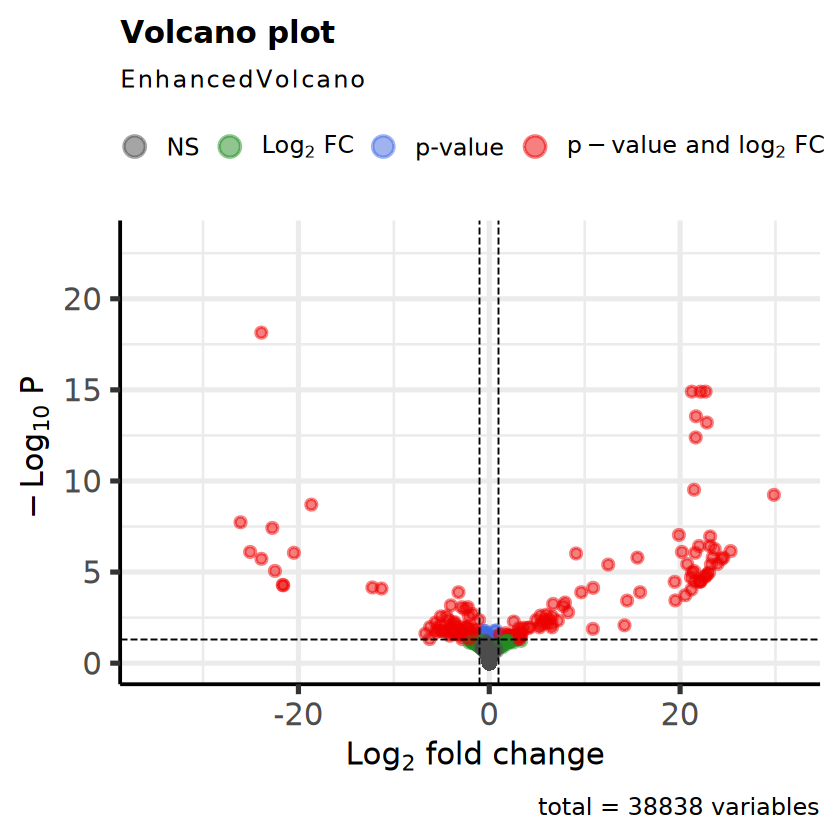

In [22]:
res.w.b <- lfcShrink(dds, 
                     contrast= c('Phase1_treatment', 'warm', 'both'), # both is the "control"
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.w.b)

EnhancedVolcano(res.w.b,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.w.b <- merge(res.w.b, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.w.b)[1] <- 'Gene'
head(res.w.b)

In [23]:
write.csv(res.w.b, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.warm_v_both.csv')

#### hypoxic vs. both

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 34981 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 91, 0.26%
LFC < -1.00 (down) : 38, 0.11%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_Nu_O03,B2_Nu_O12,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,8.739763,1.995335e-03,0.063034770,0.6928656,0.4883939,0.9912348,0.9745484,0.8524235,15.240013,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,670.509082,-4.247694e-04,0.020704990,-0.5728318,0.5667586,0.9974334,0.9836170,555.7800963,498.157926,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,160.018313,6.252352e-05,0.008552148,0.1845689,0.8535671,0.9995282,0.9881437,178.1565033,168.592644,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,13.048074,9.488539e-04,0.042645476,0.5113236,0.6091245,0.9974489,0.9789238,5.9669642,1.905002,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,403.233517,-1.021945e-04,0.013985237,-0.2017704,0.8400962,0.9995282,0.9859664,499.5201479,397.192840,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,1.594569,3.950015e-02,0.428997155,1.5807511,0.1139350,NA,0.8937078,0.0000000,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


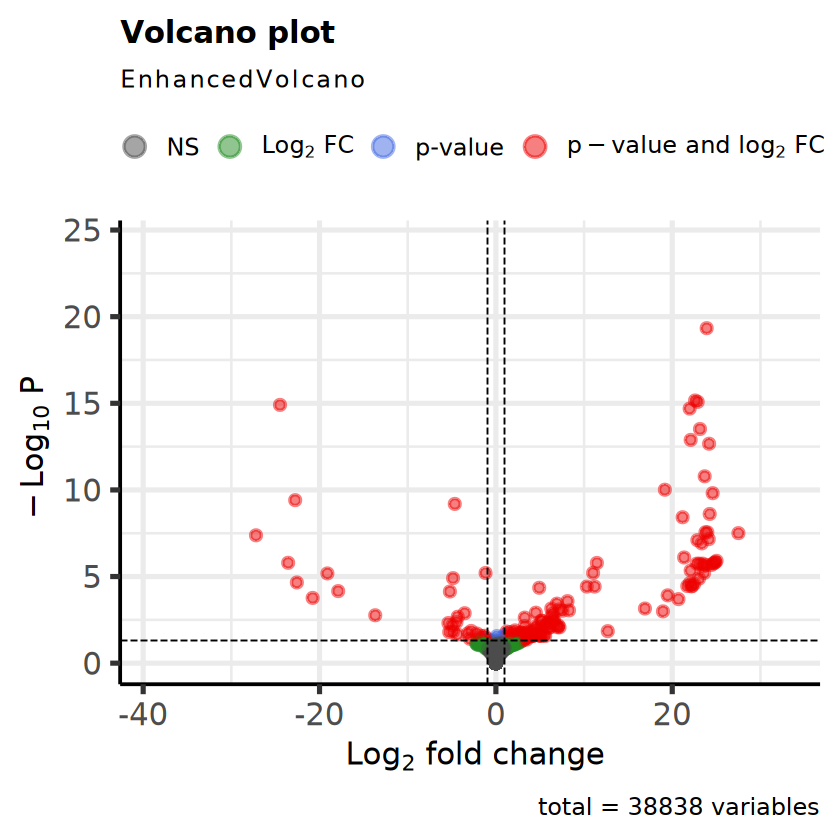

In [24]:
res.h.b <- lfcShrink(dds, 
                     contrast= c('Phase1_treatment', 'hypoxic', 'both'), # both is the "control"
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.h.b)

EnhancedVolcano(res.h.b,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.h.b <- merge(res.h.b, counts(dds, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.h.b)[1] <- 'Gene'
head(res.h.b)

In [25]:
write.csv(res.h.b, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.hyp_v_both.csv')

## DESeq - DO / warm treatments

nearly the same as above, but looking at the effect of hypoxia / warming (so normoxia includes C and W, hypoxia includes H and B; ambient includes C and H, warm includes W and B)

In [26]:
# phase 1 DO
p1_meta$Phase1_DO <- factor(p1_meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

In [14]:
# phase 1 tempature
p1_meta$Phase1_temp <- factor(p1_meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

In [15]:
head(p1_meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<fct>,<fct>,<int>,<chr>,<chr>,<chr>,<int>
B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA
B4_Nu_O32,both,warm,hypoxic,4,NA,NA,NA,NA
B5_Nu_O36,both,warm,hypoxic,5,NA,NA,NA,NA
B6_Nu_O47,both,warm,hypoxic,6,NA,NA,NA,NA
C1_Nu_W01,control,ambient,normoxic,1,NA,NA,NA,NA


### phase 1 temperature
only comparing warming vs ambient (so some treatments are getting lumped together)

In [16]:
# creating DESeq2 object
dds_temp <- DESeqDataSetFromMatrix(countData = p1_counts,
                              colData = p1_meta,
                              design = ~ Phase1_temp)
dds_temp

# running DESeq
dds_temp <- DESeq(dds_temp)

# list coefficients
resultsNames(dds_temp)

class: DESeqDataSet 
dim: 38838 23 
metadata(1): version
assays(1): counts
rownames(38838): LOC111116054 LOC111126949 ... ND1 ND4L
rowData names(0):
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(8): Phase1_treatment Phase1_temp ... Phase2_DO
  Phase2_TankRep

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2695 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



[1] "Intercept"                   "Phase1_temp_warm_vs_ambient"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 34917 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 8, 0.023%
LFC < -1.00 (down) : 19, 0.054%



Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.”


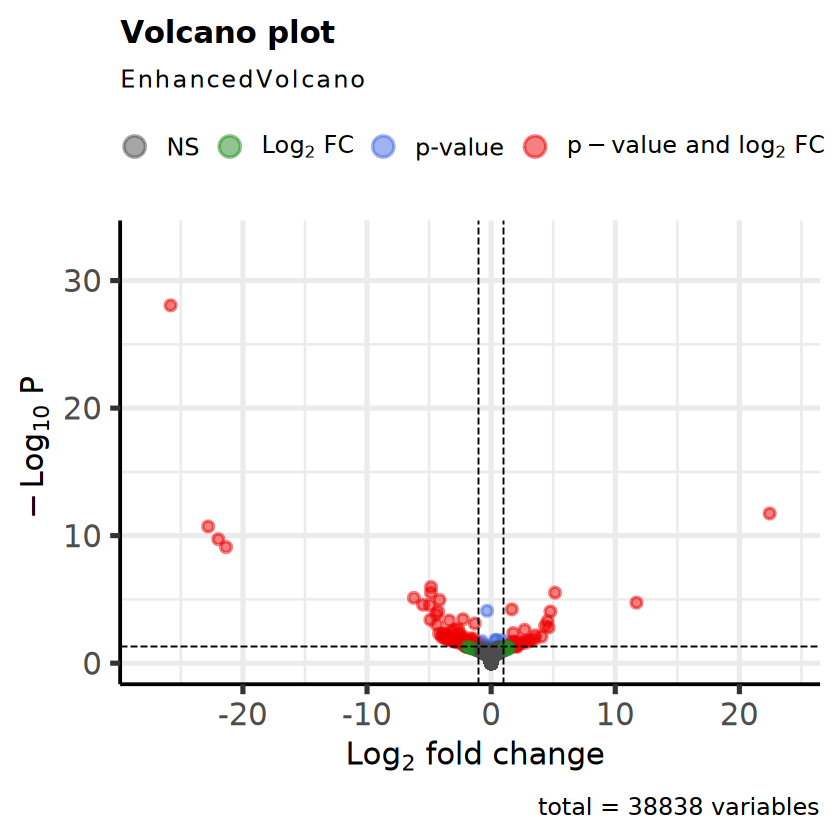

In [17]:
res.warm <- lfcShrink(dds_temp, 
                     coef = ('Phase1_temp_warm_vs_ambient'), 
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.warm)

EnhancedVolcano(res.warm,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

interesting that there's not nearly as many DEGs when you only look at ambient vs. warm treatment ...

In [20]:
write.csv(res.warm, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/warm_v_ambient.csv')

### phase 1 DO
only comparing normoxia vs hypoxia (so some treatments are getting lumped together)

In [18]:
# creating DESeq2 object
dds_DO <- DESeqDataSetFromMatrix(countData = p1_counts,
                              colData = p1_meta,
                              design = ~ Phase1_DO)
dds_DO

# running DESeq
dds_DO <- DESeq(dds_DO)

# list coefficients
resultsNames(dds_DO)

class: DESeqDataSet 
dim: 38838 23 
metadata(1): version
assays(1): counts
rownames(38838): LOC111116054 LOC111126949 ... ND1 ND4L
rowData names(0):
colnames(23): B1_Nu_O03 B2_Nu_O12 ... W6_Nu_G41 W6_Nu_G45
colData names(8): Phase1_treatment Phase1_temp ... Phase2_DO
  Phase2_TankRep

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2639 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



[1] "Intercept"                     "Phase1_DO_hypoxic_vs_normoxic"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 34919 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 9, 0.026%
LFC < -1.00 (down) : 9, 0.026%



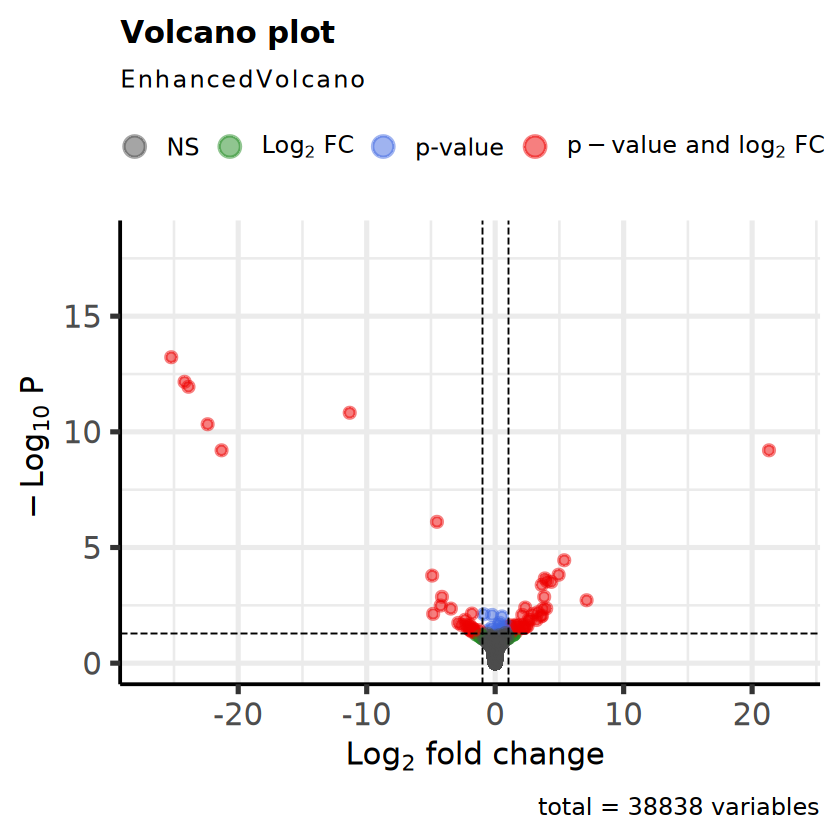

In [19]:
res.DO <- lfcShrink(dds_DO, 
                     coef = ('Phase1_DO_hypoxic_vs_normoxic'), 
                     type = 'ashr',
                    lfcThreshold = 1)

summary(res.DO)

EnhancedVolcano(res.DO,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

same thing as temperature, not as many DEGs as when separating by treatment

In [21]:
write.csv(res.DO, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/hypoxic_v_normoxic.csv')

### nMDS with only significant DEGs

In [13]:
# pull out all DEGs identified in any pairwise comparison
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/DEGs/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "DEG_b_c" "DEG_h_b" "DEG_h_c" "DEG_h_w" "DEG_w_b" "DEG_w_c"

In [17]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(X)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 487 total DEGs
head(all_degs)

[1] 487

[1] "LOC111119645" "LOC111111234" "LOC111104630" "LOC111129171" "LOC111121183"
[6] "LOC111111721"

In [20]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 487 total DEGs kept
head(degs_vsd)

[1] 487  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC111119645,6.130699,6.781034,5.935283,5.551009,6.029560,5.828779,9.343385,10.047366,10.021407,6.344075,⋯,12.011883,6.052261,9.123780,6.137978,6.060958,12.118984,6.302054,6.296690,6.705410,6.123629
LOC111112448,5.825705,5.551009,6.155955,5.551009,6.190745,6.104015,6.124216,5.551009,6.345761,7.290135,⋯,5.886606,5.906335,6.391972,6.031358,5.806977,5.873781,5.837622,5.835536,5.551009,5.883052
LOC111111234,6.891505,8.813393,7.404832,8.567154,8.518917,10.711796,9.805369,10.315947,10.600843,10.455885,⋯,7.719436,9.684464,10.046402,8.546007,6.351216,9.792164,10.452259,10.390785,9.281758,9.103283
LOC111103382,9.314511,7.183050,8.379788,9.718548,7.364255,6.516473,6.327886,8.306707,7.567524,6.731921,⋯,6.257446,6.455871,7.036808,6.724792,9.149361,8.495998,6.155574,7.299847,6.906378,6.929316
LOC111113921,7.380885,6.091895,7.442803,7.298411,7.354295,6.965730,6.436223,7.768226,7.313301,6.821040,⋯,6.513682,6.410796,6.339011,6.305396,6.331440,8.244700,7.648909,7.518156,6.818543,7.717981
LOC111110198,8.121652,8.318738,8.591929,8.884676,8.691060,8.069504,8.464426,8.316449,8.101617,8.078666,⋯,9.116048,8.998748,8.608299,8.882757,8.521418,8.060624,7.320525,7.958061,7.585922,8.029074


In [21]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.00000,31.44873,27.08159,30.33274,26.20324,32.80146,51.44384,49.49987,47.82843,36.35030,⋯,57.19443,31.73632,48.88704,36.47512,32.03290,49.37631,37.05768,36.43985,33.16333,33.97938
B2_Nu_O12,31.44873,0.00000,30.74089,35.23778,34.87251,33.53011,53.51071,50.11501,49.48209,39.02626,⋯,57.33241,35.59134,49.44966,36.24953,35.60986,49.51903,36.87322,39.36940,33.72322,37.72736
B4_Nu_O32,27.08159,30.74089,0.00000,29.90832,31.04494,33.41627,52.24974,48.99916,48.15758,37.34039,⋯,56.54926,25.51837,47.73395,35.54995,32.45650,49.41978,38.66193,36.70809,35.02752,35.32090
B5_Nu_O36,30.33274,35.23778,29.90832,0.00000,31.06733,35.16234,52.99008,50.87098,48.31672,39.01045,⋯,59.01012,33.64619,49.44167,38.32181,35.29517,53.73753,43.61309,40.09811,39.28997,37.64704
B6_Nu_O47,26.20324,34.87251,31.04494,31.06733,0.00000,35.94257,53.85530,50.90972,50.06533,40.15193,⋯,56.96474,33.46277,50.06174,38.76868,34.58801,51.95174,42.52070,37.73419,38.82657,36.91424
C1_Nu_W01,32.80146,33.53011,33.41627,35.16234,35.94257,0.00000,47.84426,45.47114,44.37203,31.38359,⋯,54.47612,33.57661,48.05337,30.89825,29.45132,48.55066,37.56008,34.58506,33.23293,31.68055


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
B1_Nu_O03,-14.97685,-8.2590198,both,warm,hypoxic,1,NA,NA,NA,NA,1.1731259
B2_Nu_O12,-14.09169,-3.6002684,both,warm,hypoxic,2,NA,NA,NA,NA,1.0498679
B4_Nu_O32,-14.49447,-10.3978488,both,warm,hypoxic,4,NA,NA,NA,NA,1.1954800
B5_Nu_O36,-14.65065,-15.7839368,both,warm,hypoxic,5,NA,NA,NA,NA,0.8890653
B6_Nu_O47,-15.04066,-13.1941983,both,warm,hypoxic,6,NA,NA,NA,NA,0.9604278
C1_Nu_W01,-10.67558,-0.2855303,control,ambient,normoxic,1,NA,NA,NA,NA,1.1472252


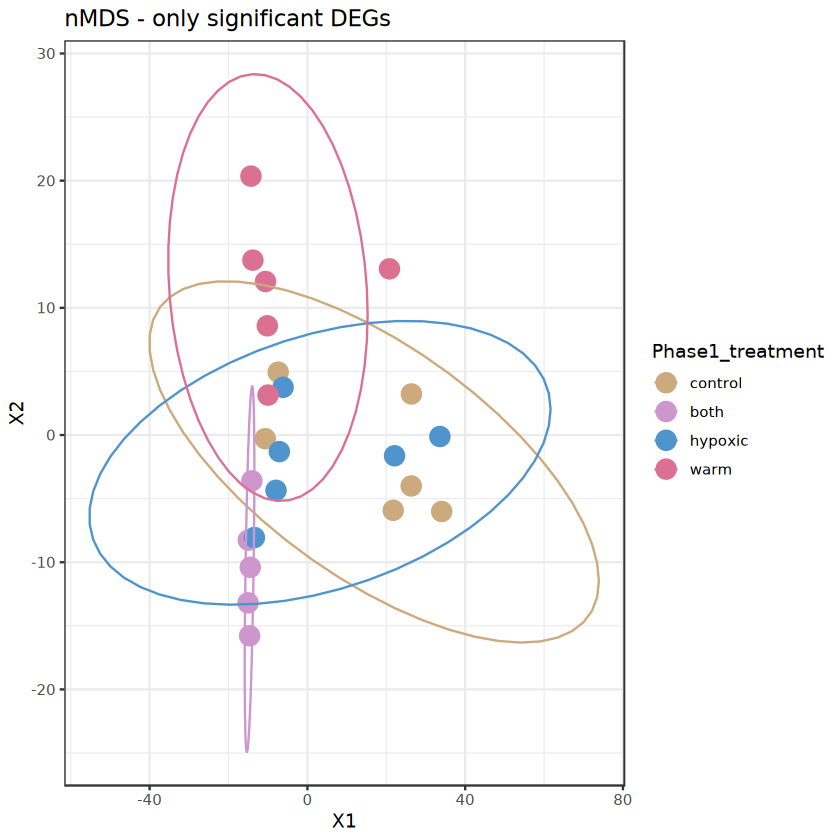

In [24]:
ggplot(mds, aes(X1, X2, col = Phase1_treatment)) +
geom_point(size = 5) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
stat_ellipse() + 
labs(title = 'nMDS - only significant DEGs') +
theme_bw()

In [33]:
meta3 <- meta2[meta2$Sample %in% rownames(mds),]

#### permanova

In [34]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO , data = meta3, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,2865.373,0.14604544,3.902312,0.004
Phase1_DO,1,1640.294,0.08360425,2.233893,0.045
Phase1_temp:Phase1_DO,1,1162.833,0.05926853,1.583646,0.112
Residual,19,13951.238,0.71108178,NA,NA
Total,22,19619.738,1.00000000,NA,NA


significant effect of phase 1 temp and DO, but no interaction of the two stressors (there wasn't any significant effects when we looked at all genes, but once limited to significant DEGs idnetified in any pairwise comparison (not isolated treatments), we saw significant effects on GE profiles)

### nMDS with only significant DEGs from 'isolated' treatments

In [46]:
# pull out DEGs identified 

# read in dfs
do <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/hypoxic_v_normoxic.csv')
temp <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/warm_v_ambient.csv')

# merge
degs <- rbind(do, temp) %>%
filter(padj < 0.05 & abs(log2FoldChange) > 1) 

deg_list <- unique(degs$X)
length(deg_list)# 156 total DEGs
head(deg_list)

[1] 156

[1] "LOC111120718" "LOC111126792" "LOC111100876" "LOC111108404" "LOC111122008"
[6] "LOC111121842"

In [48]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% deg_list,]

dim(degs_vsd) # 156 total DEGs kept
head(degs_vsd)

[1] 156  23

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
LOC111119645,6.130699,6.781034,5.935283,5.551009,6.029560,5.828779,9.343385,10.047366,10.021407,6.344075,⋯,12.011883,6.052261,9.123780,6.137978,6.060958,12.118984,6.302054,6.296690,6.705410,6.123629
LOC111120718,6.974121,9.500134,7.099381,9.916729,6.345381,6.621548,6.298084,6.565135,6.130987,6.941675,⋯,6.294854,6.433657,7.331143,11.107699,6.555794,7.135239,6.085041,6.322265,6.102094,6.418332
LOC111129171,5.551009,5.551009,5.551009,5.551009,5.551009,5.551009,5.551009,6.822375,7.993563,5.551009,⋯,9.455840,5.551009,5.551009,5.551009,5.551009,5.551009,5.551009,5.551009,5.551009,5.551009
LOC111122541,7.889227,8.740517,6.984052,7.477032,8.653750,7.148829,7.168249,6.665230,7.184567,7.276042,⋯,6.591929,7.636331,7.062309,7.619725,7.635703,8.769232,9.415245,8.094044,7.200427,9.530120
LOC111135260,6.343101,6.128764,6.289271,7.772738,7.194113,7.586153,12.060798,12.272877,12.602378,6.708320,⋯,14.082015,6.128851,8.801784,6.768330,7.024012,8.561485,6.187768,6.594447,6.269495,6.418332
LOC111134528,6.130699,6.854642,6.312944,5.996159,5.979427,6.374385,11.427884,10.450939,10.286033,7.358239,⋯,12.647165,6.650674,9.956870,7.228057,6.425426,13.317045,6.654188,6.117343,6.377882,6.019564


In [49]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,C4_Nu_W29,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
B1_Nu_O03,0.00000,19.82789,21.01101,22.69420,18.08454,21.04669,29.63270,28.18654,27.85102,25.12117,⋯,31.93043,22.98381,25.74666,24.21053,19.38522,26.90652,23.10269,21.82516,22.88392,21.26328
B2_Nu_O12,19.82789,0.00000,18.74465,23.24386,21.09067,19.95451,31.09486,28.87068,29.10142,25.58091,⋯,33.72152,21.51832,25.85473,22.42481,21.94545,27.79283,21.59733,23.36198,25.65264,21.99185
B4_Nu_O32,21.01101,18.74465,0.00000,22.58376,21.17275,21.56144,30.29747,27.23700,27.64027,26.08538,⋯,30.89974,14.07792,24.22283,23.47566,19.19963,26.84598,23.72109,21.87945,26.95960,22.20245
B5_Nu_O36,22.69420,23.24386,22.58376,0.00000,21.35253,22.61144,29.12832,26.54328,26.34544,26.12700,⋯,32.23652,23.43821,23.63861,25.01428,20.86113,26.70390,26.00905,22.50297,24.44124,22.40955
B6_Nu_O47,18.08454,21.09067,21.17275,21.35253,0.00000,19.49323,29.40592,26.73486,27.87078,26.36919,⋯,31.07985,21.80643,25.62185,24.06829,19.57100,28.21507,24.44183,19.75768,26.79383,21.94987
C1_Nu_W01,21.04669,19.95451,21.56144,22.61144,19.49323,0.00000,26.37936,24.89975,24.62768,21.02295,⋯,30.41253,21.83821,23.30317,18.98689,16.48351,27.08543,22.55717,19.65997,25.22249,18.37097


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,sizeFactor
,<dbl>,<dbl>,<fct>,<fct>,<fct>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
B1_Nu_O03,-7.374337,0.96485859,both,warm,hypoxic,1,NA,NA,NA,NA,1.1731259
B2_Nu_O12,-9.653353,-1.30190474,both,warm,hypoxic,2,NA,NA,NA,NA,1.0498679
B4_Nu_O32,-6.914338,-4.84706967,both,warm,hypoxic,4,NA,NA,NA,NA,1.1954800
B5_Nu_O36,-5.115823,-0.07817643,both,warm,hypoxic,5,NA,NA,NA,NA,0.8890653
B6_Nu_O47,-7.181944,-3.28921291,both,warm,hypoxic,6,NA,NA,NA,NA,0.9604278
C1_Nu_W01,-4.743642,-2.60847590,control,ambient,normoxic,1,NA,NA,NA,NA,1.1472252


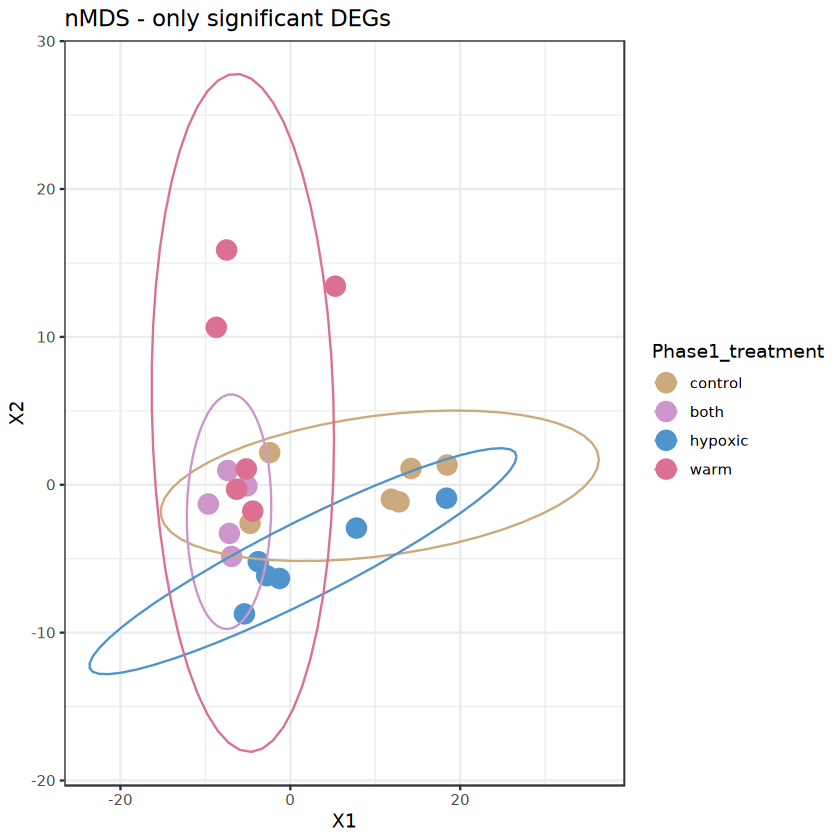

In [50]:
ggplot(mds, aes(X1, X2, col = Phase1_treatment)) +
geom_point(size = 5) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
stat_ellipse() + 
labs(title = 'nMDS - only significant DEGs') +
theme_bw()

different patterns here vs. when we looked at all DEGs identified in any pairwise comparisons for phase 1 vs. phase 1
- warm is more dispersed
- both has tigher clustering

#### permanova

In [51]:
meta3 <- meta2[meta2$Sample %in% rownames(mds),]

In [52]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO , data = meta3, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,992.3929,0.14043291,3.5994266,0.001
Phase1_DO,1,628.9771,0.08900617,2.2813112,0.007
Phase1_temp:Phase1_DO,1,206.8356,0.02926918,0.7501965,0.750
Residual,19,5238.4634,0.74129174,NA,NA
Total,22,7066.6691,1.00000000,NA,NA
